In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
import os
print(os.getcwd())

C:\Users\KARTHIK GOUD


In [7]:
import os
print(os.listdir("apexplanet-data-analytics/data"))

['.ipynb_checkpoints', 'raw', 'Superstore sales dataset.csv']


In [8]:
df = pd.read_csv("apexplanet-data-analytics/data/Superstore sales dataset.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12/6/2016,16/6/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

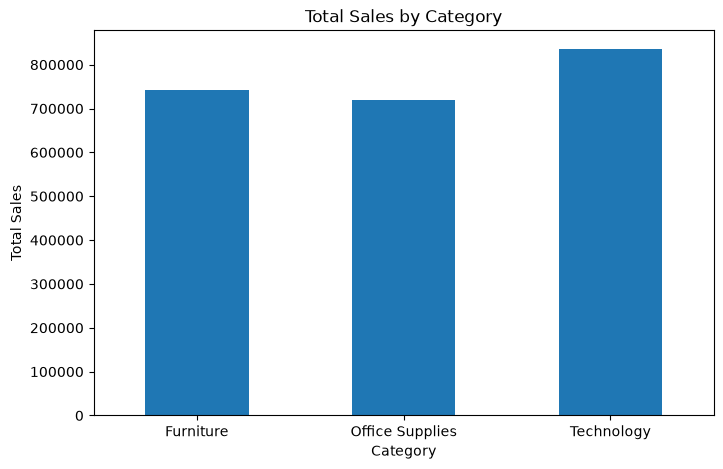

In [10]:
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8, 5))
category_sales.plot(kind="bar")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

In [12]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True,
    errors="coerce"
)

print(df["Order Date"].head())
print("Missing dates:", df["Order Date"].isna().sum())

0   2016-11-08
1   2016-11-08
2   2016-06-12
3   2015-10-11
4   2015-10-11
Name: Order Date, dtype: datetime64[us]
Missing dates: 0


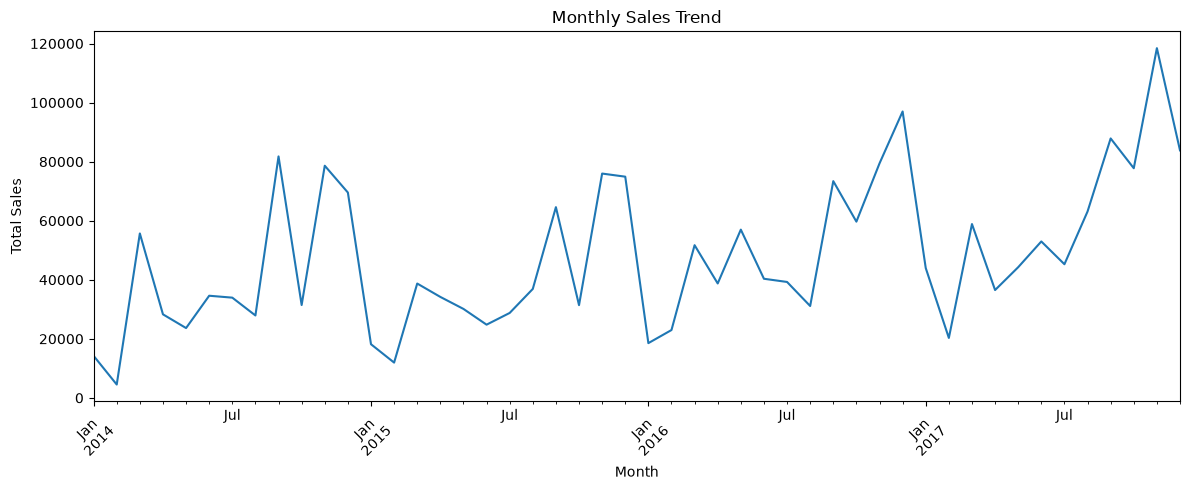

In [13]:
monthly_sales = df.groupby(
    df["Order Date"].dt.to_period("M")
)["Sales"].sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot(kind="line")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

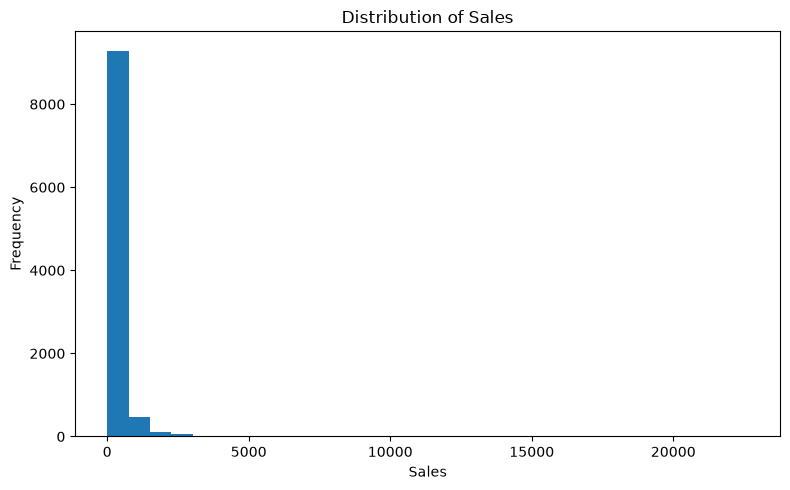

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(df["Sales"], bins=30)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

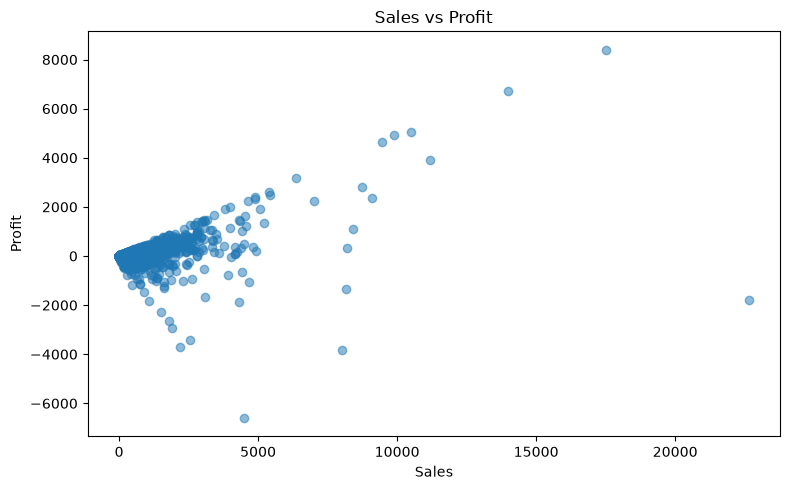

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Sales"], df["Profit"], alpha=0.5)
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

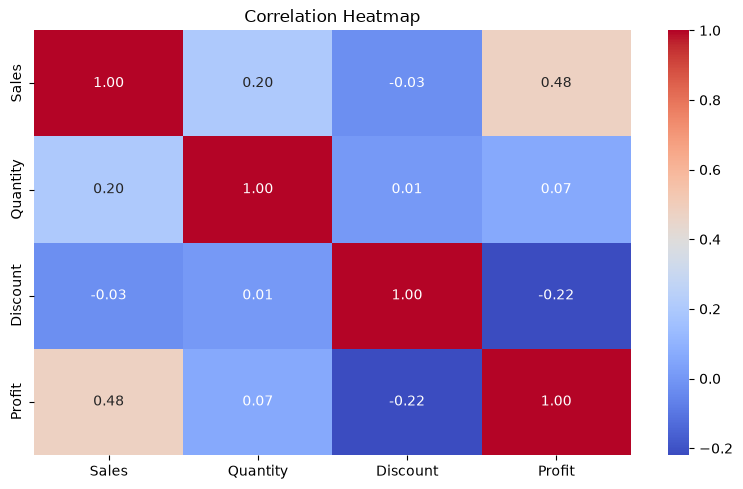

In [16]:
numeric_cols = ["Sales", "Quantity", "Discount", "Profit"]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

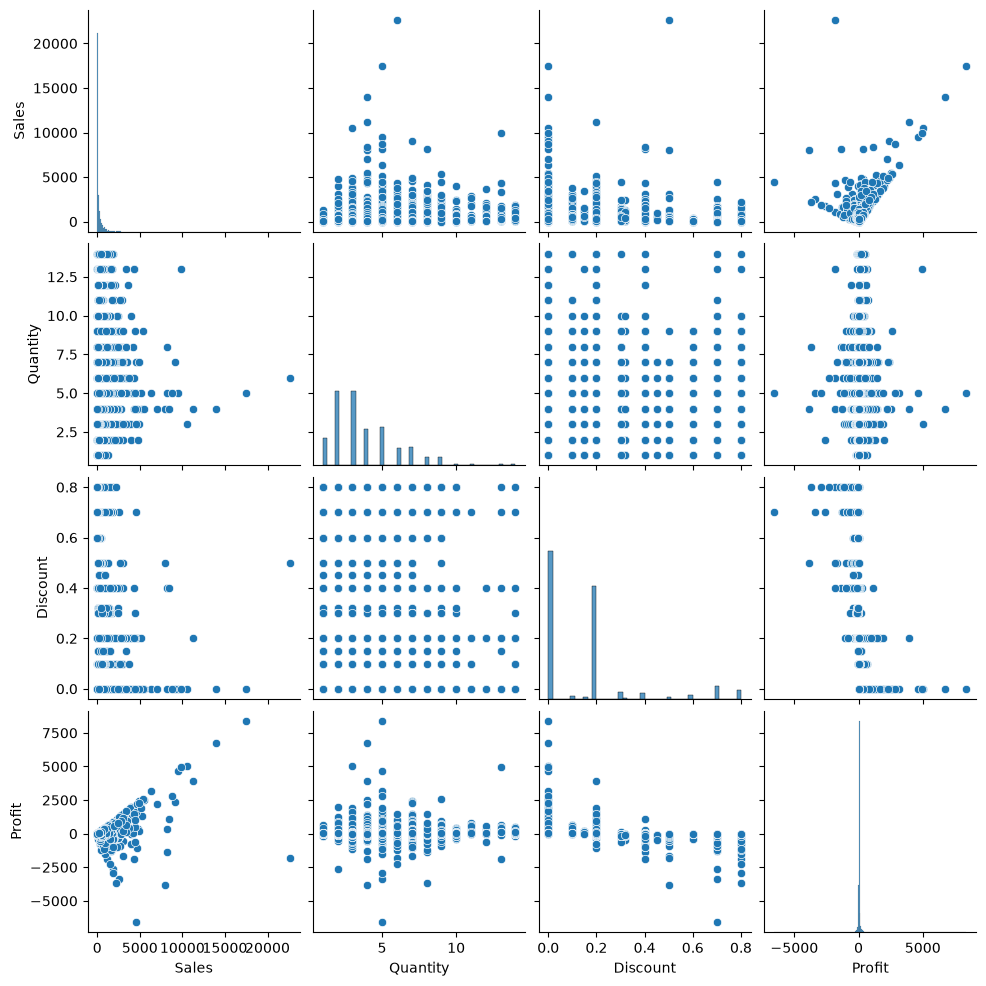

In [17]:
sns.pairplot(
    df[["Sales", "Quantity", "Discount", "Profit"]]
)

plt.show()

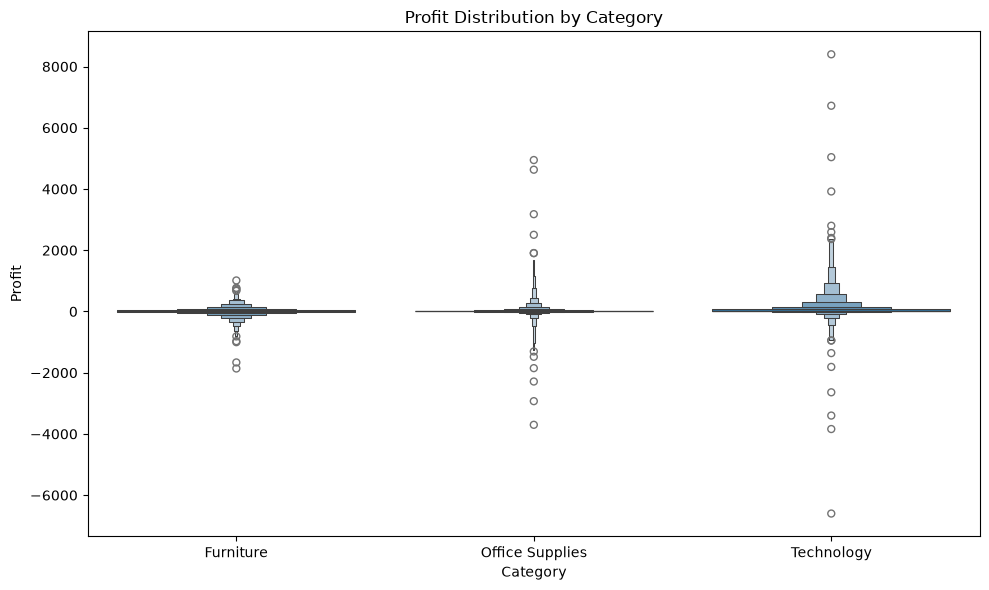

In [18]:
plt.figure(figsize=(10, 6))

sns.boxenplot(
    data=df,
    x="Category",
    y="Profit"
)

plt.title("Profit Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

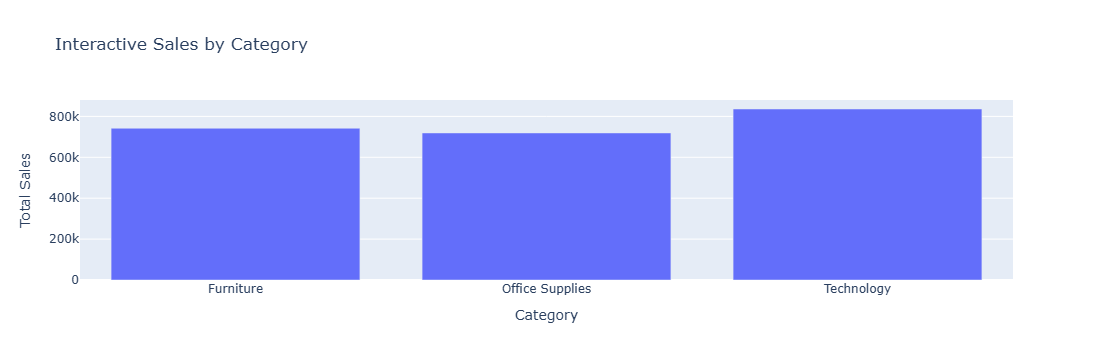

In [19]:
fig = px.bar(
    df.groupby("Category", as_index=False)["Sales"].sum(),
    x="Category",
    y="Sales",
    title="Interactive Sales by Category",
    labels={"Sales": "Total Sales"}
)

fig.show()

In [20]:
fig.write_html(
    "apexplanet-data-analytics/dashboards/sales_by_category.html"
)

print("Plotly chart saved successfully!")

Plotly chart saved successfully!
